In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nikhil7280/student-performance-multiple-linear-regression/Student_Performance.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nikhil7280/student-performance-multiple-linear-regression/Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
df.shape

(10000, 6)

In [5]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [6]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [8]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [9]:
df.corr

<bound method DataFrame.corr of       Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0                 7               99                        Yes            9   
1                 4               82                         No            4   
2                 8               51                        Yes            7   
3                 5               52                        Yes            5   
4                 7               75                         No            8   
...             ...              ...                        ...          ...   
9995              1               49                        Yes            4   
9996              7               64                        Yes            8   
9997              6               83                        Yes            8   
9998              9               97                        Yes            7   
9999              7               74                         No            8   

      S

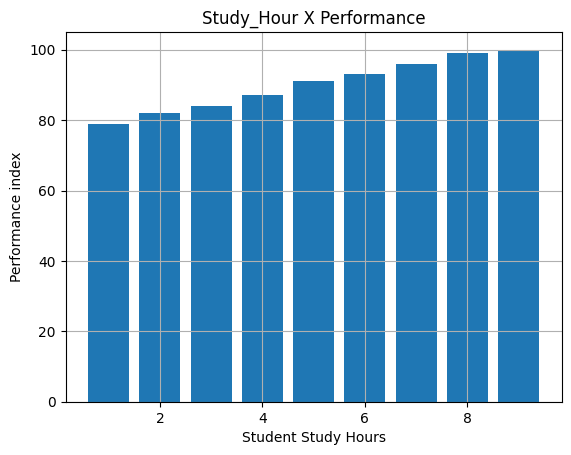

In [10]:
plt.bar(df['Hours Studied'],df['Performance Index'])
plt.xlabel('Student Study Hours')
plt.ylabel('Performance index')
plt.title('Study_Hour X Performance')
plt.grid(True)

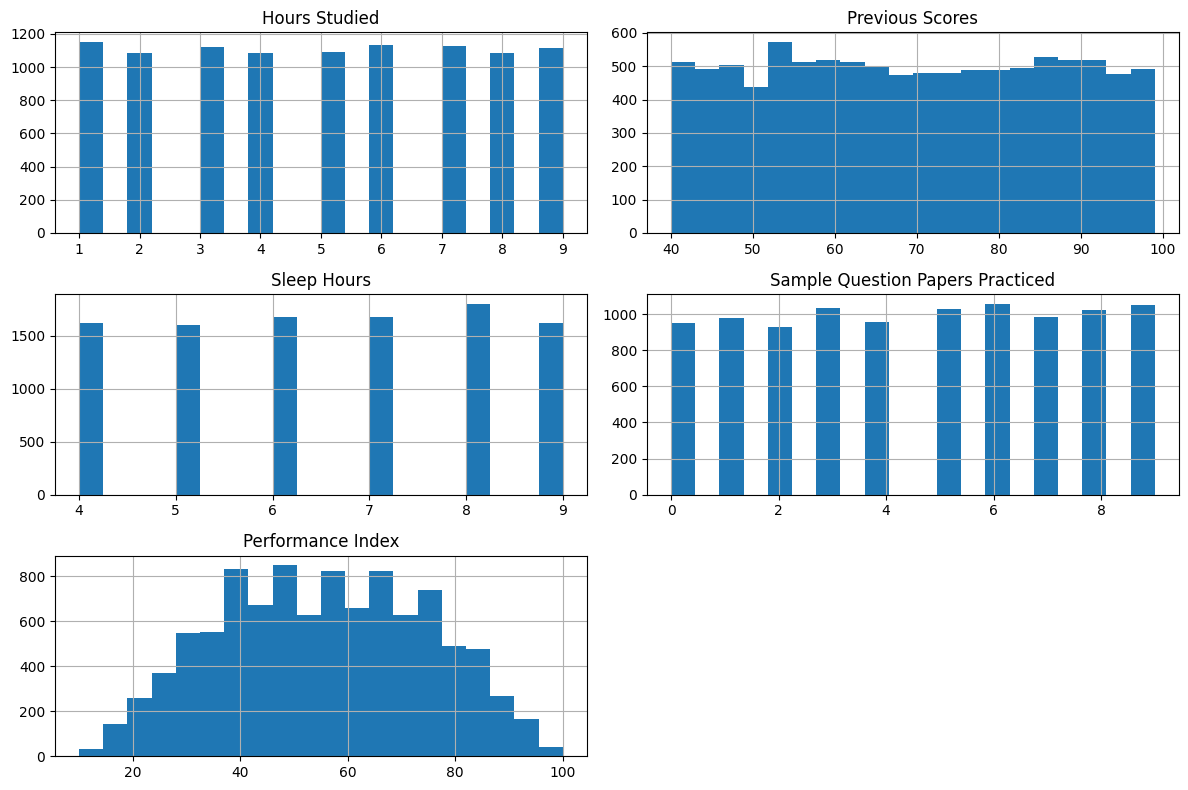

In [11]:
num_cols = ['Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced',
    'Performance Index']
df[num_cols].hist(figsize=(12,8),bins=20)
plt.title("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

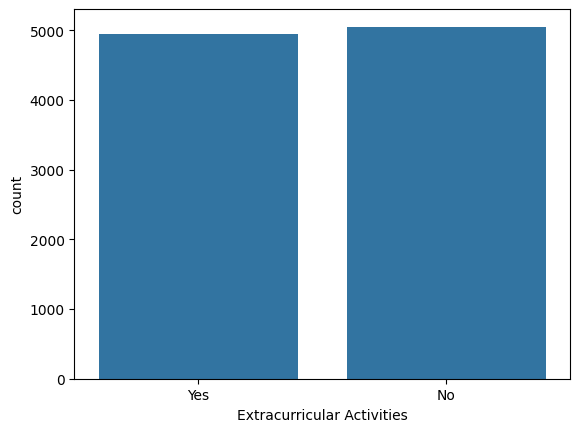

In [12]:
# Categorical Feature
sns.countplot(x='Extracurricular Activities',data=df)
plt.show()

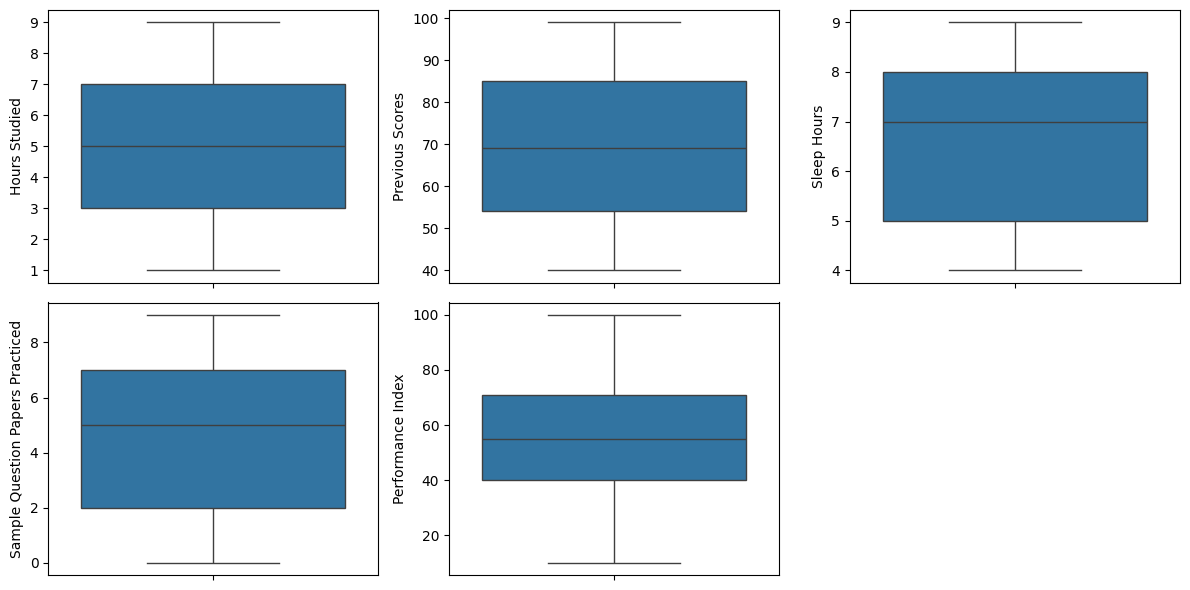

In [13]:
plt.figure(figsize=(12,6))

for i,col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
plt.tight_layout()
plt.show()

<Axes: >

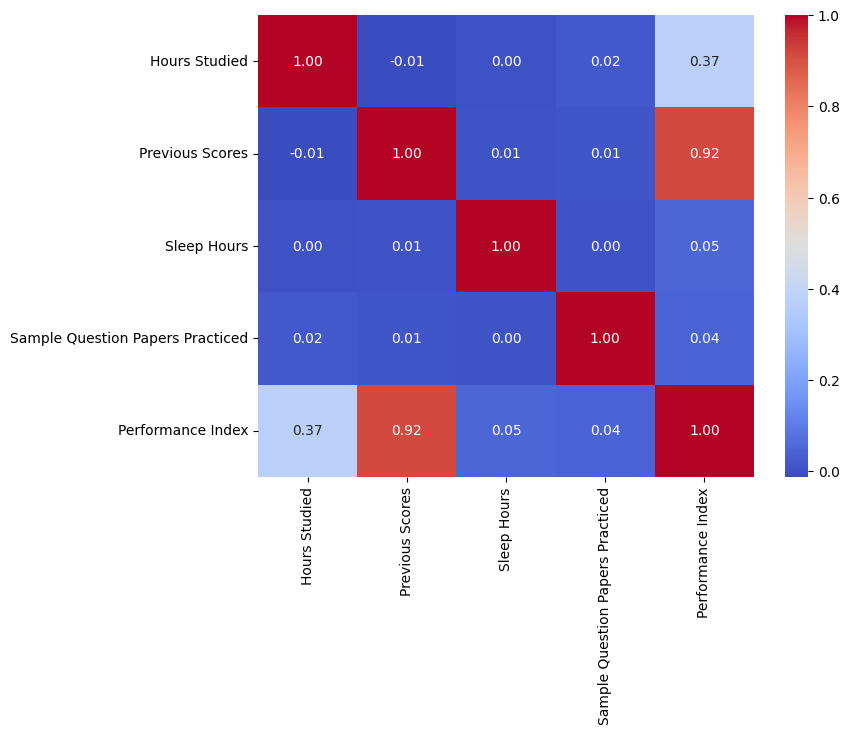

In [14]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
           annot=True,cmap='coolwarm',fmt='.2f')

In [15]:
X = df.drop('Performance Index',axis=1)
y = df['Performance Index']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(8000, 5)
(2000, 5)


# **From sklearn Linear Regression**

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

num_features = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced'
]

cat_features = ['Extracurricular Activities']

preprocessor = ColumnTransformer(
    transformers =[
        ('num',StandardScaler(),num_features),
        ('cat',OneHotEncoder(drop='first'),cat_features)
    ]
)

In [17]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])

In [18]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Hours Studied',
                                                   'Previous Scores',
                                                   'Sleep Hours',
                                                   'Sample Question Papers '
                                                   'Practiced']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Extracurricular '
                                                   'Activities'])])),
                ('model', LinearRegression())])

In [19]:
y_pred = pipe.predict(X_test)

In [20]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9889832909573145

# **Making  our own Linear Regression Class**
# **Formula =(X^T . X)^-1 . X^T y**

In [21]:
X_train_trf = preprocessor.fit_transform(X_train)
X_test_trf = preprocessor.transform(X_test)

In [22]:
X_train_trf

array([[ 0.00645547, -1.18384439,  0.26988848,  0.13404112,  0.        ],
       [-1.14974745, -1.24150571,  0.26988848,  0.48356164,  1.        ],
       [-1.14974745,  0.66131759,  0.26988848, -0.91452044,  0.        ],
       ...,
       [ 1.54805935, -1.24150571,  0.26988848,  0.48356164,  0.        ],
       [-1.53514842, -1.29916702,  1.4474766 , -1.61356148,  0.        ],
       [-1.14974745, -1.35682833, -0.31890558,  0.48356164,  0.        ]])

In [23]:
class  MyLR():
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)

        #Calculate the coefficients using the normal equation
        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]
    def predict(self,X_test):
        y_pred = np.dot(X_test,self.coef_)+self.intercept_
        return y_pred
    

In [24]:
model = MyLR()
model.fit(X_train_trf,y_train)

In [25]:
model.coef_

array([ 7.40134079, 17.63727127,  0.81003107,  0.54884171,  0.60861668])

In [26]:
model.intercept_

np.float64(55.010462974864524)

In [27]:
y_pred = model.predict(X_test_trf)

In [28]:
from sklearn.metrics import r2_score ,mean_absolute_error

print("R2_score :",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))

R2_score : 0.9889832909573145
MAE: 1.6111213463123049


In [29]:
results = pd.DataFrame({
    'Actual':y_test.values,
    'predicted':y_pred
})
results.head(10)

,Actual,predicted
0,51.0,54.711854
1,20.0,22.615513
2,46.0,47.903145
3,28.0,31.289767
4,41.0,43.004570
5,59.0,59.071252
6,48.0,45.903475
7,87.0,86.459118
8,37.0,37.700140
9,73.0,72.055925


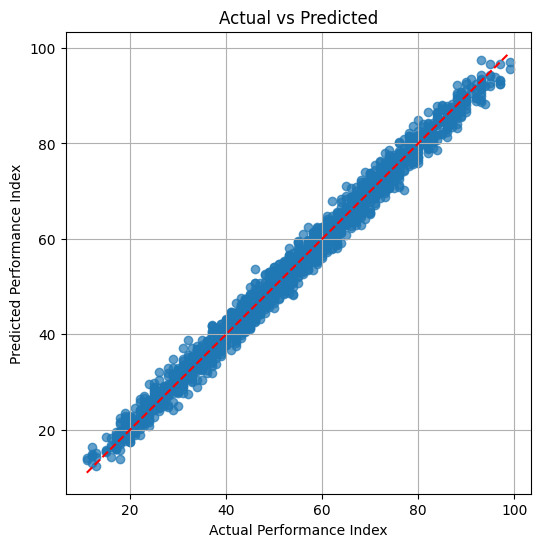

In [30]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred,alpha=0.7)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Performance Index")
plt.ylabel('Predicted Performance Index')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()